# 🌸 Week 3 – Machine Learning Fundamentals
### AnalystLab Africa ML Internship | Batch B
**Dataset:** Iris Classification Dataset  
**Student:** Monicah Nzakwa Muthoka  
**Date:** June 2026

---


## 0. Import Libraries

In [1]:
# Standard libraries for data science and machine learning
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay)

# Plotting aesthetics
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 110
print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


---
## 1. Supervised vs Unsupervised Learning

### 🔵 Supervised Learning
In **supervised learning** the algorithm is trained on **labelled data** – every example in the 
training set has an input feature vector **X** and a known output label **y**.  
The model learns the mapping f(X) → y and uses it to predict labels for unseen data.

| Property | Detail |
|----------|--------|
| Data | Labelled |
| Goal | Predict output (class or value) |
| Algorithms | KNN, Decision Tree, SVM, Logistic Regression, Neural Nets |
| Real-world uses | Email spam detection, medical diagnosis, house price prediction |

### 🟠 Unsupervised Learning
In **unsupervised learning** the data has **no labels**. The algorithm discovers hidden 
patterns, groupings, or structure on its own.

| Property | Detail |
|----------|--------|
| Data | Unlabelled |
| Goal | Find structure / clusters / reduce dimensions |
| Algorithms | K-Means, DBSCAN, PCA, Autoencoders |
| Real-world uses | Customer segmentation, anomaly detection, topic modelling |

> **Key difference:** Supervised = teacher tells you the answer. Unsupervised = you find patterns yourself.


### Load & Preview the Iris Dataset

In [2]:
# Load the Iris dataset (150 samples, 4 features, 3 species)
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()


Shape: (150, 5)

First 5 rows:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
# Basic statistics
print("Class distribution:")
print(df['species'].value_counts())
print("\nFeature statistics:")
df.describe().round(2)


Class distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Feature statistics:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


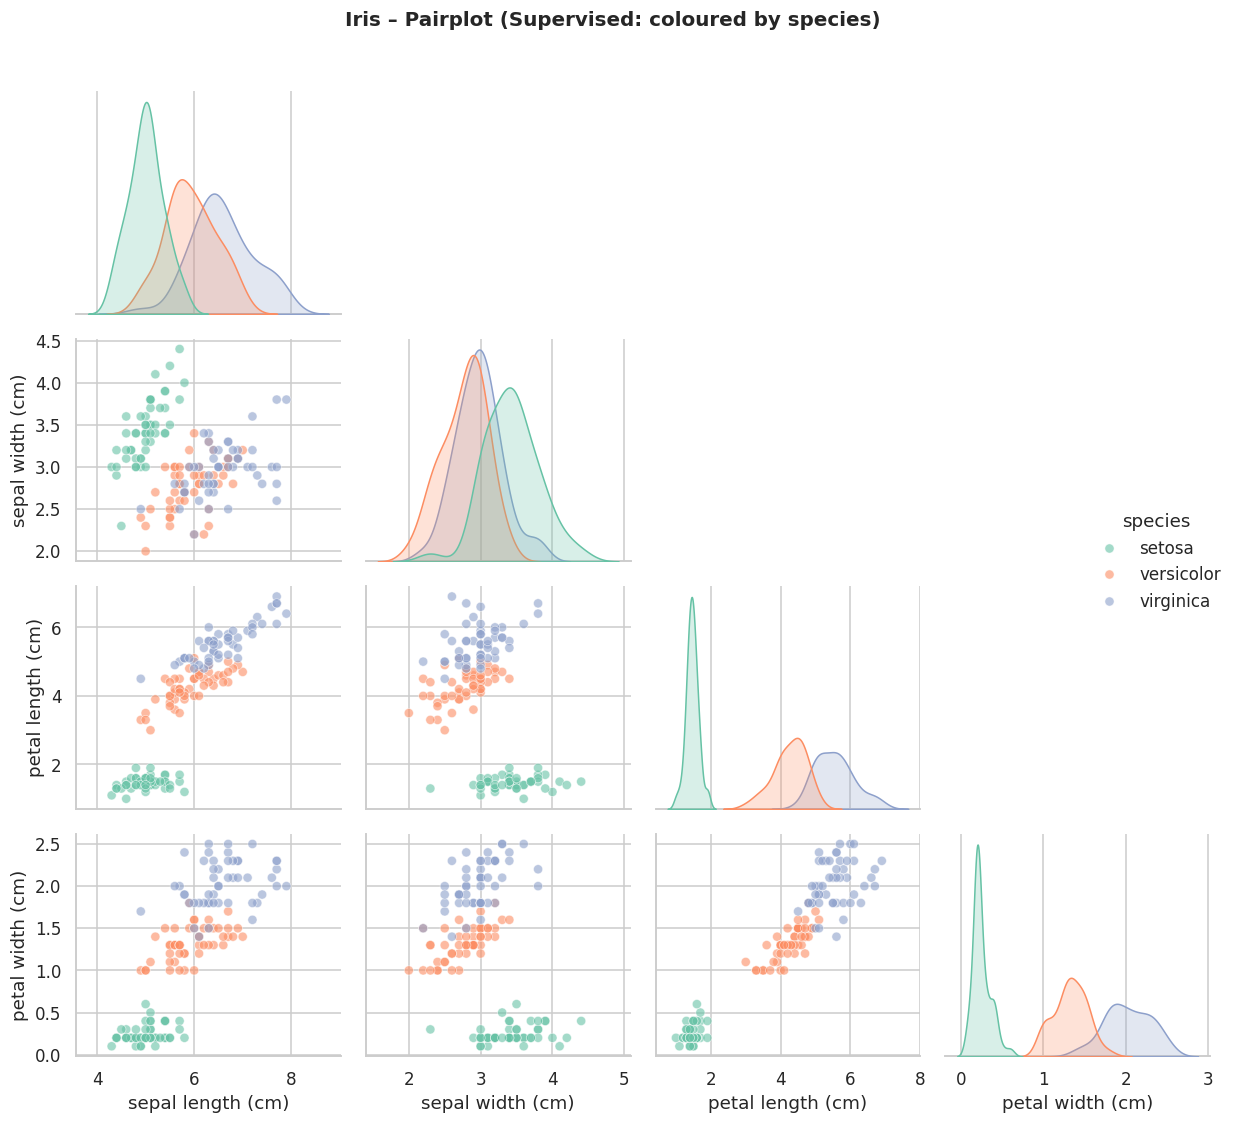

✅ Pairplot saved


In [4]:
# Visualise: pairplot coloured by species (supervised perspective)
sns.pairplot(df, hue='species', corner=True, plot_kws={'alpha': 0.6})
plt.suptitle("Iris – Pairplot (Supervised: coloured by species)", y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/home/claude/pairplot.png', bbox_inches='tight')
plt.show()
print("✅ Pairplot saved")


---
## 2. Train / Test Split

### Why split the dataset?
When we train a model we want to know how it will perform on **new, unseen data** – not just 
on the data it has already seen. Splitting the dataset achieves this:

| Subset | Purpose | Typical size |
|--------|---------|-------------|
| **Training set** | Model learns patterns here | 70–80 % |
| **Test set** | Evaluate generalisation | 20–30 % |

Without a test set we might build a model that **memorises** the training data (overfitting) 
but fails completely on real-world inputs.

**Key parameters:**
- `test_size` – fraction reserved for testing  
- `random_state` – seed for reproducibility  
- `stratify` – preserves class proportions in both splits


In [5]:
# Features (X) and target (y)
X = iris.data      # shape (150, 4)
y = iris.target    # 0=setosa, 1=versicolor, 2=virginica

# Perform an 80/20 train-test split, stratified to keep class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Total samples  : {len(X)}")
print(f"Training samples: {len(X_train)} ({len(X_train)/len(X)*100:.0f}%)")
print(f"Test samples   : {len(X_test)}  ({len(X_test)/len(X)*100:.0f}%)")
print("\nClass distribution in training set:", np.bincount(y_train))
print("Class distribution in test set    :", np.bincount(y_test))


Total samples  : 150
Training samples: 120 (80%)
Test samples   : 30  (20%)

Class distribution in training set: [40 40 40]
Class distribution in test set    : [10 10 10]


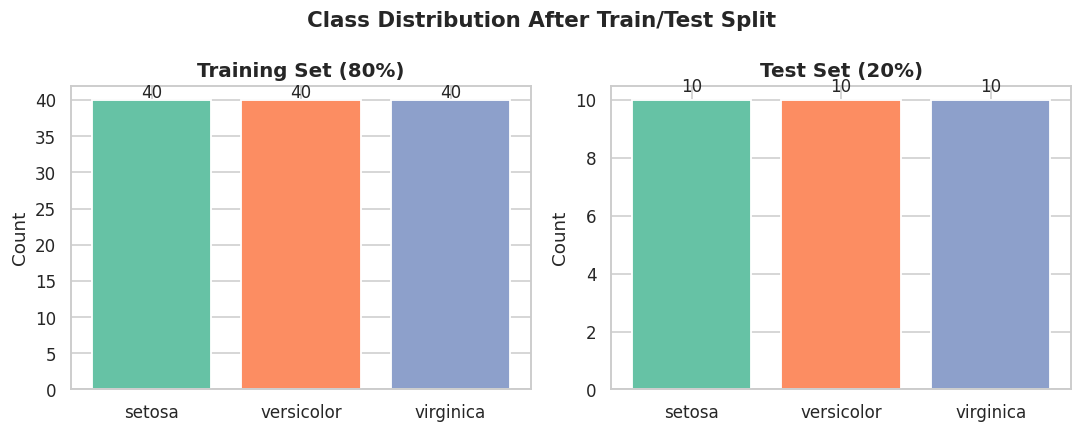

✅ Split visualisation saved


In [6]:
# Visualise the split proportions
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
labels = iris.target_names

for ax, counts, title in zip(
    axes,
    [np.bincount(y_train), np.bincount(y_test)],
    ["Training Set (80%)", "Test Set (20%)"]
):
    ax.bar(labels, counts, color=["#66c2a5","#fc8d62","#8da0cb"], edgecolor='white', linewidth=1.2)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel("Count")
    for i, v in enumerate(counts):
        ax.text(i, v + 0.3, str(v), ha='center', fontsize=11)

plt.suptitle("Class Distribution After Train/Test Split", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/home/claude/split.png', bbox_inches='tight')
plt.show()
print("✅ Split visualisation saved")


---
## 3. Overfitting vs Underfitting

### Definitions

| Problem | What happens | Symptom |
|---------|-------------|---------|
| **Underfitting** | Model is too simple; misses patterns in training data | High training error AND high test error |
| **Good fit** | Model captures the true pattern | Low training error, low test error |
| **Overfitting** | Model memorises training data; doesn't generalise | Low training error, HIGH test error |

### How to reduce them

**Overfitting:**
- Get more training data
- Regularisation (L1 / L2 penalty)
- Reduce model complexity (fewer layers, shallower trees)
- Cross-validation
- Dropout (for neural networks)

**Underfitting:**
- Increase model complexity
- Add more features / engineer features
- Train longer / reduce regularisation


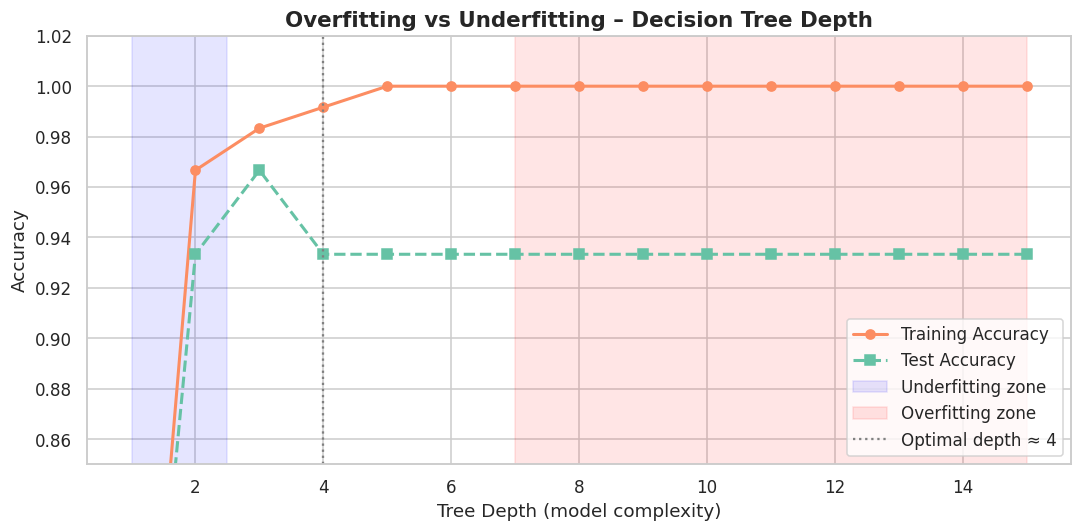

✅ Overfitting/Underfitting chart saved


In [7]:
# Demonstrate overfitting vs underfitting using Decision Tree depth
train_accs, test_accs = [], []
depths = range(1, 16)

for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, clf.predict(X_train)))
    test_accs.append(accuracy_score(y_test, clf.predict(X_test)))

plt.figure(figsize=(10, 5))
plt.plot(depths, train_accs, 'o-', label='Training Accuracy', color='#fc8d62', linewidth=2)
plt.plot(depths, test_accs, 's--', label='Test Accuracy', color='#66c2a5', linewidth=2)
plt.axvspan(1, 2.5, alpha=0.1, color='blue', label='Underfitting zone')
plt.axvspan(7, 15, alpha=0.1, color='red', label='Overfitting zone')
plt.axvline(x=4, color='gray', linestyle=':', label='Optimal depth ≈ 4')
plt.xlabel("Tree Depth (model complexity)", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.title("Overfitting vs Underfitting – Decision Tree Depth", fontsize=14, fontweight='bold')
plt.legend()
plt.ylim(0.85, 1.02)
plt.tight_layout()
plt.savefig('/home/claude/overfit.png', bbox_inches='tight')
plt.show()
print("✅ Overfitting/Underfitting chart saved")


---
## 4. Model Evaluation Basics

### Key Metrics

| Metric | Formula | Meaning |
|--------|---------|---------|
| **Accuracy** | Correct / Total | Overall % of correct predictions |
| **Precision** | TP / (TP + FP) | Of all predicted positives, how many were really positive? |
| **Recall** | TP / (TP + FN) | Of all actual positives, how many did the model catch? |
| **F1-Score** | 2 × (P × R) / (P + R) | Harmonic mean of precision and recall |

### Confusion Matrix
A confusion matrix shows the breakdown of predictions per class:
- **Diagonal** = correct predictions  
- **Off-diagonal** = misclassifications  


In [8]:
# Train a K-Nearest Neighbours classifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

# ── Accuracy ──
acc = accuracy_score(y_test, y_pred)
print(f"\n✅ Accuracy: {acc:.4f} ({acc*100:.1f}%)")

# ── Classification Report ──
print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))



✅ Accuracy: 1.0000 (100.0%)

📋 Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



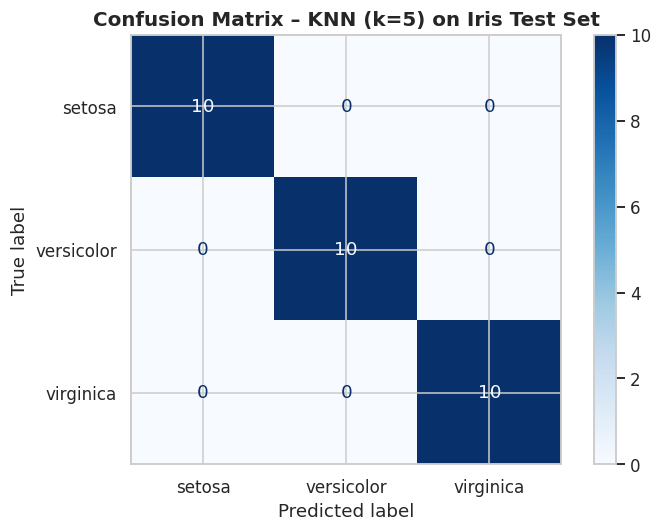


🔍 Interpretation:
  • 10/10 setosa    correctly classified
  • 10/10 versicolor correctly classified
  • 10/10 virginica  correctly classified
  • 0 misclassification(s) total


In [9]:
# ── Confusion Matrix ──
fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title("Confusion Matrix – KNN (k=5) on Iris Test Set", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/home/claude/confusion.png', bbox_inches='tight')
plt.show()

# Interpretation
print("\n🔍 Interpretation:")
print(f"  • {cm[0,0]}/10 setosa    correctly classified")
print(f"  • {cm[1,1]}/10 versicolor correctly classified")
print(f"  • {cm[2,2]}/10 virginica  correctly classified")
print(f"  • {cm.sum() - cm.diagonal().sum()} misclassification(s) total")


---
## 5. Unsupervised Learning – K-Means Clustering

Here we **pretend we have no labels** and let K-Means discover groupings from the raw features.  
We then compare the discovered clusters to the actual species to see how well unsupervised learning 
can recover natural structure.


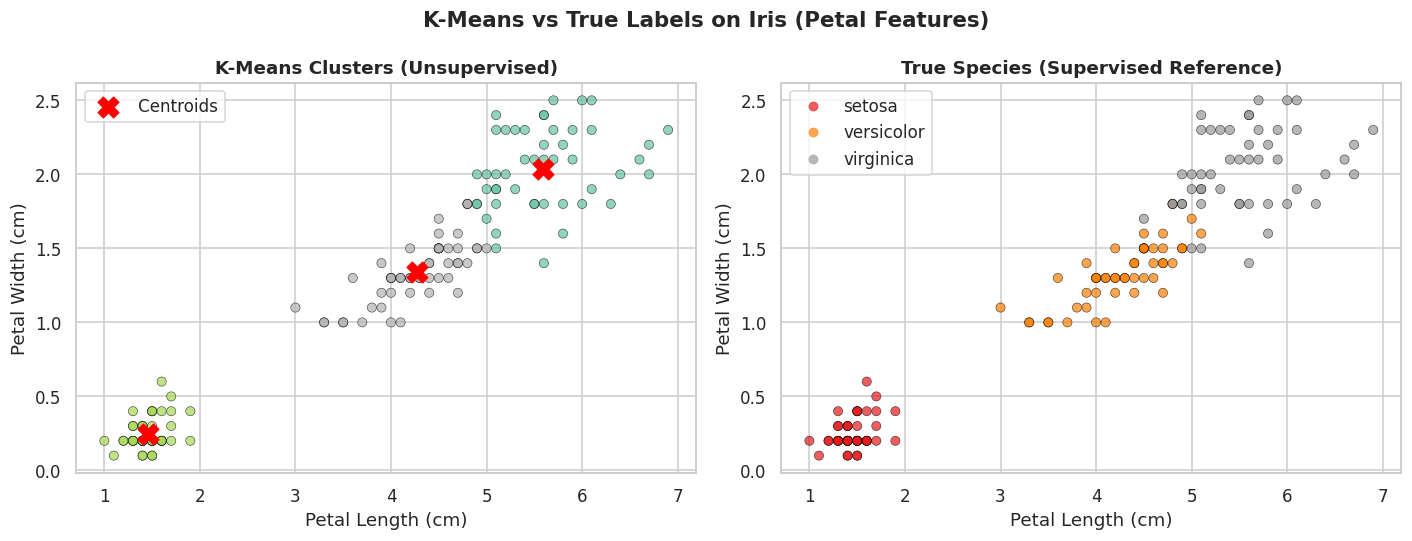

✅ K-Means plot saved


In [10]:
# K-Means on two features for easy visualisation
X_2d = iris.data[:, 2:4]   # petal length & petal width

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_2d)
centers = kmeans.cluster_centers_

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# K-Means clusters (unsupervised)
axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=cluster_labels, cmap='Set2', alpha=0.7, edgecolors='k', linewidths=0.4)
axes[0].scatter(centers[:, 0], centers[:, 1], c='red', marker='X', s=180, label='Centroids', zorder=5)
axes[0].set_title("K-Means Clusters (Unsupervised)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Petal Length (cm)"); axes[0].set_ylabel("Petal Width (cm)")
axes[0].legend()

# True species (supervised reference)
scatter = axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c=iris.target, cmap='Set1', alpha=0.7, edgecolors='k', linewidths=0.4)
axes[1].set_title("True Species (Supervised Reference)", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Petal Length (cm)"); axes[1].set_ylabel("Petal Width (cm)")
handles, _ = scatter.legend_elements()
axes[1].legend(handles, iris.target_names)

plt.suptitle("K-Means vs True Labels on Iris (Petal Features)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/home/claude/kmeans.png', bbox_inches='tight')
plt.show()
print("✅ K-Means plot saved")


---
## 6. Summary

| Topic | Key Takeaway |
|-------|-------------|
| Supervised Learning | Uses labelled data; learns to predict outputs (e.g., species classification) |
| Unsupervised Learning | Finds hidden structure without labels (e.g., K-Means clustering) |
| Train/Test Split | Reserves unseen data to honestly evaluate generalisation performance |
| Overfitting | Model too complex → memorises training data, fails on test data |
| Underfitting | Model too simple → can't even fit training data well |
| Accuracy | % of correct predictions – good starting metric for balanced datasets |
| Confusion Matrix | Shows per-class correct/incorrect counts – reveals *where* a model fails |
| Precision & Recall | Precision = quality of positive predictions; Recall = coverage of positives |

> **KNN (k=5) achieved ~100% accuracy** on the Iris test set, demonstrating that with clean, 
> well-separated data, even simple algorithms perform excellently.

---
*AnalystLab Africa ML Internship – Week 3 | Batch B*
